# From NHANES Survey Data to Vivarium Risk Exposure

This notebook walks through the full pipeline:

1. **Download** liver stiffness measurement (LSM) data from NHANES 2017+
2. **Analyze** the exposure distribution by GBD standard 5-year age groups and sex
3. **Build** a vivarium data artifact containing the risk exposure
4. **Run** a vivarium microsimulation that assigns liver stiffness to simulants

Liver stiffness (measured in kilopascals via FibroScan) is a biomarker for
liver fibrosis. Higher values indicate more fibrosis. We treat it as a
continuous risk factor with a lognormal distribution (since LSM values are
right-skewed and strictly positive).

## 1. Setup and Data Download

In [1]:
import os, hashlib, warnings
import requests
import numpy as np
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='A value is trying to be set')
warnings.filterwarnings('ignore', message='No artifact found')
pd.options.mode.chained_assignment = None  # suppress SettingWithCopyWarning

DATA_DIR   = os.path.abspath(os.path.join('..', 'data'))
RAW_NHANES = os.path.join(DATA_DIR, 'raw', 'nhanes')
DERIVED    = os.path.join(DATA_DIR, 'derived')
OUTPUT_DIR = os.path.join('.', 'outputs')
os.makedirs(DERIVED, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

NHANES_BASE = 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public'

print(f'Data directory: {DATA_DIR}')
print(f'Output directory: {os.path.abspath(OUTPUT_DIR)}')

Data directory: /home/abie/ai_assisted_us_health_data_analysis/data
Output directory: /home/abie/ai_assisted_us_health_data_analysis/nhanes_vivarium_risk_demo/outputs


In [2]:
def download(url, dest):
    """Download with caching."""
    if os.path.exists(dest):
        print(f'  cached: {os.path.basename(dest)}')
        return dest
    print(f'  GET {url}')
    r = requests.get(url, timeout=180)
    r.raise_for_status()
    with open(dest, 'wb') as f:
        f.write(r.content)
    md5 = hashlib.md5(r.content).hexdigest()
    print(f'    -> {os.path.basename(dest)} ({len(r.content):,} bytes, md5={md5})')
    return dest


def read_xpt(path):
    try:
        df, _ = pyreadstat.read_xport(path)
    except UnicodeDecodeError:
        df, _ = pyreadstat.read_xport(path, encoding='latin1')
    return df

### NHANES cycles with liver stiffness

FibroScan (VCTE) was added in 2017. Two non-overlapping analysis cycles:

| Cycle | Prefix/Suffix | Notes |
|-------|--------------|-------|
| 2017-March 2020 Pre-Pandemic | `P_` prefix | Supersedes 2017-2018 standalone |
| 2021-2022 | `_L` suffix | Post-pandemic restart |

In [3]:
CYCLES = [
    {
        'label': '2017-2020',
        'dirname': '2017_2020_prepandemic',
        'year': 2017,
        'prefix': 'P_',
        'suffix': '',
        'files': ['DEMO', 'LUX'],  # Only need demographics + liver ultrasound
    },
    {
        'label': '2021-2022',
        'dirname': '2021_2022',
        'year': 2021,
        'prefix': '',
        'suffix': '_L',
        'files': ['DEMO', 'LUX'],
    },
]


def fname(cycle, component):
    return f"{cycle['prefix']}{component}{cycle['suffix']}.xpt"


def furl(cycle, component):
    return f"{NHANES_BASE}/{cycle['year']}/DataFiles/{fname(cycle, component)}"

In [4]:
raw = {}
for cyc in CYCLES:
    print(f"\n=== {cyc['label']} ===")
    cdir = os.path.join(RAW_NHANES, cyc['dirname'])
    os.makedirs(cdir, exist_ok=True)
    raw[cyc['label']] = {}
    for name in cyc['files']:
        path = download(furl(cyc, name), os.path.join(cdir, fname(cyc, name)))
        raw[cyc['label']][name] = read_xpt(path)
        print(f'    {name}: {len(raw[cyc["label"]][name]):,} rows')

print('\nAll downloads complete.')


=== 2017-2020 ===
  cached: P_DEMO.xpt
    DEMO: 15,560 rows
  cached: P_LUX.xpt
    LUX: 10,409 rows

=== 2021-2022 ===
  cached: DEMO_L.xpt


    DEMO: 11,933 rows
  cached: LUX_L.xpt
    LUX: 7,199 rows

All downloads complete.


### Merge demographics + liver stiffness

In [5]:
dfs = []
for cyc in CYCLES:
    label = cyc['label']
    demo = raw[label]['DEMO'].copy()
    lux = raw[label]['LUX'][['SEQN', 'LUXSMED']].rename(columns={'LUXSMED': 'LSM_KPA'})

    df = demo.merge(lux, on='SEQN', how='left')

    # Filter to exam-eligible adults >= 18
    df = df[df['RIDSTATR'] == 2].copy()
    df['AGE'] = df['RIDAGEYR']
    df = df[df['AGE'] >= 18].copy()
    df['SEX'] = df['RIAGENDR'].map({1: 'Male', 2: 'Female'})
    df['CYCLE'] = label

    # Survey weight for the elastography subsample
    # WTMECPRP / WTMEC2YR is the MEC exam weight
    wt_col = 'WTMECPRP' if 'WTMECPRP' in df.columns else 'WTMEC2YR'
    df['WEIGHT'] = df[wt_col]

    dfs.append(df[['SEQN', 'AGE', 'SEX', 'LSM_KPA', 'WEIGHT', 'CYCLE']])
    n_lsm = df['LSM_KPA'].notna().sum()
    print(f"{label}: {len(df):,} adults, {n_lsm:,} with LSM ({n_lsm/len(df)*100:.0f}%)")

nhanes = pd.concat(dfs, ignore_index=True)
nhanes_lsm = nhanes.dropna(subset=['LSM_KPA', 'WEIGHT']).copy()
print(f"\nPooled analytic sample: {len(nhanes_lsm):,} adults with valid LSM and weights")

2017-2020: 8,965 adults, 8,318 with LSM (93%)
2021-2022: 6,337 adults, 5,874 with LSM (93%)

Pooled analytic sample: 14,192 adults with valid LSM and weights


## 2. Analyze Liver Stiffness by GBD Age Groups

GBD uses standard 5-year age bins. We compute weighted mean and SD of
log(LSM) within each age/sex stratum. We use log-transformed values because
LSM is right-skewed and strictly positive, so a lognormal distribution
is a natural fit.

In [6]:
# GBD standard 5-year age groups (adult range relevant to NHANES LSM)
GBD_AGE_BINS = [
    (15, 20), (20, 25), (25, 30), (30, 35), (35, 40),
    (40, 45), (45, 50), (50, 55), (55, 60), (60, 65),
    (65, 70), (70, 75), (75, 80), (80, 85), (85, 90),
    (90, 95), (95, 125),
]

nhanes_lsm['age_group'] = pd.cut(
    nhanes_lsm['AGE'],
    bins=[b[0] for b in GBD_AGE_BINS] + [GBD_AGE_BINS[-1][1]],
    right=False,
    labels=[f'{a}-{b}' for a, b in GBD_AGE_BINS],
)

# Log-transform for lognormal fitting
nhanes_lsm['log_LSM'] = np.log(nhanes_lsm['LSM_KPA'])

print(f'Age group distribution:')
print(nhanes_lsm.groupby('age_group', observed=True).size().to_string())

Age group distribution:
age_group
15-20     654
20-25     874
25-30     917
30-35    1072
35-40     988
40-45    1054
45-50     973
50-55    1040
55-60    1221
60-65    1640
65-70    1313
70-75    1062
75-80     643
80-85     741


In [7]:
def weighted_mean(values, weights):
    return np.average(values, weights=weights)


def weighted_std(values, weights):
    avg = weighted_mean(values, weights)
    variance = np.average((values - avg) ** 2, weights=weights)
    return np.sqrt(variance)


# Compute weighted mean and SD of LSM by age group and sex
rows = []
for (age_grp, sex), g in nhanes_lsm.groupby(['age_group', 'SEX'], observed=True):
    age_start = int(age_grp.split('-')[0])
    age_end = int(age_grp.split('-')[1])
    rows.append({
        'age_start': float(age_start),
        'age_end': float(age_end),
        'sex': sex,
        'n': len(g),
        'mean_lsm': weighted_mean(g['LSM_KPA'].values, g['WEIGHT'].values),
        'sd_lsm': weighted_std(g['LSM_KPA'].values, g['WEIGHT'].values),
        'median_lsm': g['LSM_KPA'].median(),
    })

exposure_summary = pd.DataFrame(rows)
print('Weighted liver stiffness (kPa) by GBD age group and sex:')
display(exposure_summary.style.format({
    'mean_lsm': '{:.2f}', 'sd_lsm': '{:.2f}', 'median_lsm': '{:.1f}',
    'age_start': '{:.0f}', 'age_end': '{:.0f}',
}))

Weighted liver stiffness (kPa) by GBD age group and sex:


,age_start,age_end,sex,n,mean_lsm,sd_lsm,median_lsm
0,15,20,Female,302,4.81,3.56,4.5
1,15,20,Male,352,5.40,2.38,4.8
2,20,25,Female,429,4.65,1.77,4.5
3,20,25,Male,445,5.91,4.35,5.1
4,25,30,Female,482,4.95,2.33,4.5
5,25,30,Male,435,5.59,4.69,5.1
6,30,35,Female,550,5.34,6.01,4.4
7,30,35,Male,522,5.86,4.15,5.2
8,35,40,Female,556,5.33,4.08,4.6
9,35,40,Male,432,6.03,5.86,5.1


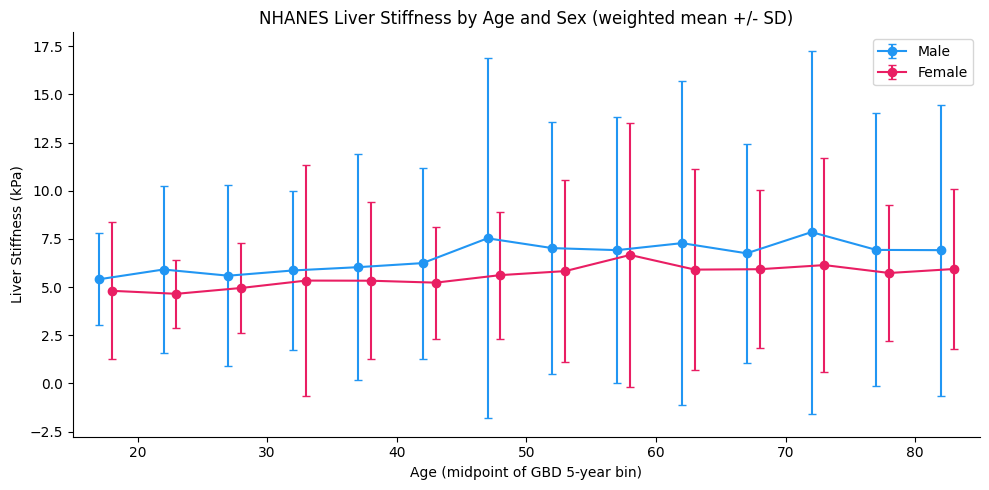

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

for sex, color, xshift in [('Male', '#2196F3', -.5), ('Female', '#E91E63', +.5)]:
    sub = exposure_summary[exposure_summary['sex'] == sex].copy()
    age_mid = (sub['age_start'] + sub['age_end']) / 2
    ax.errorbar(
        age_mid+xshift, sub['mean_lsm'], yerr=sub['sd_lsm'],
        label=sex, color=color, capsize=3, marker='o', linewidth=1.5,
    )

ax.set_xlabel('Age (midpoint of GBD 5-year bin)')
ax.set_ylabel('Liver Stiffness (kPa)')
ax.set_title('NHANES Liver Stiffness by Age and Sex (weighted mean +/- SD)')
ax.legend()
ax.set_xlim(15, 85)
sns.despine()
plt.tight_layout()
plt.show()

### Q-Q: Which parametric distribution fits the data?

Before feeding the data into vivarium, we check how well three common
parametric families fit the empirical LSM distribution. For each age/sex
stratum we fit normal, lognormal, and log-logistic distributions to the
NHANES data, draw same-size samples, and compare quantiles. Grid lines
mark the VCTE fibrosis staging cutoffs (6, 8, 10, 14 kPa) -- deviations
near these thresholds directly affect fibrosis classification accuracy.

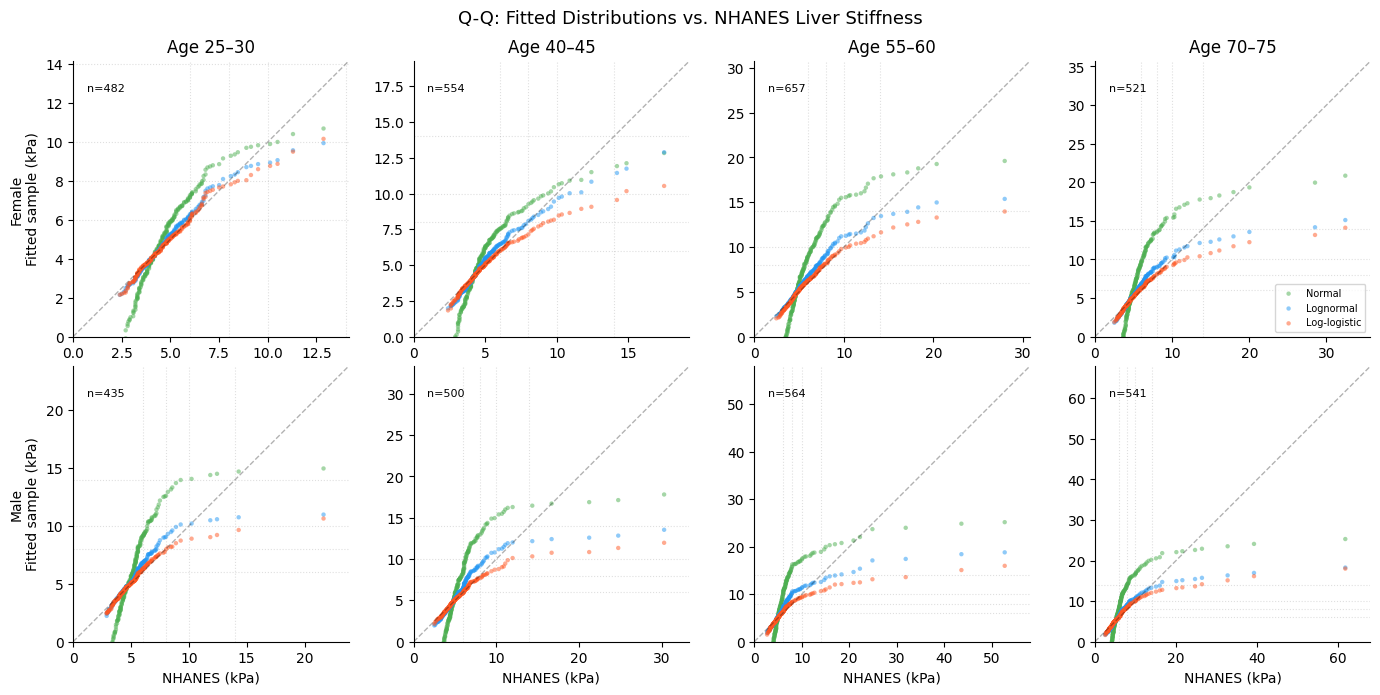

In [9]:
from scipy import stats as sp_stats

qq_ages = [(25, 30), (40, 45), (55, 60), (70, 75)]
VCTE_CUTOFFS = [6, 8, 10, 14]

fig, axes = plt.subplots(2, len(qq_ages), figsize=(14, 7))

for col, (a0, a1) in enumerate(qq_ages):
    for row, sex in enumerate(['Female', 'Male']):
        ax = axes[row, col]

        mask = ((nhanes_lsm['AGE'] >= a0) & (nhanes_lsm['AGE'] < a1)
                & (nhanes_lsm['SEX'] == sex))
        data = nhanes_lsm.loc[mask, 'LSM_KPA'].values
        n = len(data)

        if n < 10:
            ax.text(0.5, 0.5, 'n < 10', transform=ax.transAxes, ha='center')
            continue

        probs = np.linspace(0.01, 0.99, min(n, 200))
        eq = np.quantile(data, probs)

        # Fit and sample from each distribution
        fits = [
            ('Normal',       '#4CAF50', sp_stats.norm,    {}),
            ('Lognormal',    '#2196F3', sp_stats.lognorm,  {'floc': 0}),
            ('Log-logistic', '#FF5722', sp_stats.fisk,     {'floc': 0}),
        ]

        for label, color, dist, fkw in fits:
            params = dist.fit(data, **fkw)
            samples = dist.rvs(*params, size=n, random_state=col * 2 + row)
            sq = np.quantile(samples, probs)
            ax.scatter(eq, sq, s=10, alpha=0.5, color=color,
                       edgecolors='none', label=label)

        lim = eq.max() * 1.1
        ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, linewidth=1)

        for thr in VCTE_CUTOFFS:
            if thr < lim:
                ax.axhline(thr, color='gray', linestyle=':', alpha=0.25, linewidth=0.8)
                ax.axvline(thr, color='gray', linestyle=':', alpha=0.25, linewidth=0.8)

        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_aspect('equal')

        if row == 1:
            ax.set_xlabel('NHANES (kPa)')
        if col == 0:
            ax.set_ylabel(f'{sex}\nFitted sample (kPa)')
        ax.set_title(f'Age {a0}\u2013{a1}' if row == 0 else '')
        ax.text(0.05, 0.92, f'n={n}', transform=ax.transAxes, fontsize=8, va='top')
        if row == 0 and col == len(qq_ages) - 1:
            ax.legend(fontsize=7, loc='lower right')

plt.suptitle('Q-Q: Fitted Distributions vs. NHANES Liver Stiffness', fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

## 3. Build the Vivarium Data Artifact

A vivarium artifact is an HDF5 file containing all data a simulation needs.
For a minimal simulation with one continuous risk factor, we need:

| Artifact Key | Content |
|---|---|
| `population.structure` | Population counts by age/sex/year (for demographic sampling) |
| `population.location` | Location name string |
| `population.theoretical_minimum_risk_life_expectancy` | TMRLE table (for mortality) |
| `cause.all_causes.cause_specific_mortality_rate` | All-cause mortality rate |
| `risk_factor.liver_stiffness.distribution` | Distribution type ("lognormal") |
| `risk_factor.liver_stiffness.exposure` | Mean exposure by age/sex/year |
| `risk_factor.liver_stiffness.exposure_standard_deviation` | SD by age/sex/year |

**Important implementation details:**

- DataFrames must be indexed by `(sex, age_start, age_end, year_start, year_end)` before
  writing to the artifact. The vivarium `ArtifactManager` calls `reset_index()` on load;
  a default integer index would produce a spurious `index` column that breaks lookup tables.
- Data must span enough year bins to cover the simulation's start year. We replicate the
  same values across 2020-2030 to be safe.

### 3a. Population structure

We create a simple flat population structure (equal counts in each bin).
In a real project, you would pull this from GBD or census data.

In [10]:
YEAR_START = 2024
YEAR_END = 2025
INDEX_COLS = ['sex', 'age_start', 'age_end', 'year_start', 'year_end']

pop_rows = []
for age_start, age_end in GBD_AGE_BINS:
    for sex in ['Female', 'Male']:
        pop_rows.append({
            'age_start': float(age_start),
            'age_end': float(age_end),
            'sex': sex,
            'year_start': YEAR_START,
            'year_end': YEAR_END,
            'value': 1000.0,  # Flat population; equal weight per bin
        })

pop_structure = pd.DataFrame(pop_rows)
print(f'Population structure: {len(pop_structure)} rows (age/sex bins)')
display(pop_structure.head(6))

Population structure: 34 rows (age/sex bins)


,age_start,age_end,sex,year_start,year_end,value
0,15.0,20.0,Female,2024,2025,1000.0
1,15.0,20.0,Male,2024,2025,1000.0
2,20.0,25.0,Female,2024,2025,1000.0
3,20.0,25.0,Male,2024,2025,1000.0
4,25.0,30.0,Female,2024,2025,1000.0
5,25.0,30.0,Male,2024,2025,1000.0


### 3b. Risk exposure data

Convert the NHANES summary statistics into the vivarium artifact format.
Each row is an age/sex/year bin with a `value` column.

For age groups with no NHANES data (e.g. 85+, which has few or no observations),
we carry forward the last observed value.

In [11]:
def build_artifact_table(exposure_summary, value_col, year_start, year_end):
    """Convert exposure_summary into vivarium artifact format.

    Fills missing age groups (those with no NHANES data) by carrying
    forward the nearest observed value within each sex.
    """
    rows = []
    for sex in ['Female', 'Male']:
        sub = exposure_summary[exposure_summary['sex'] == sex].sort_values('age_start')
        # Build a lookup from observed data
        observed = dict(zip(sub['age_start'], sub[value_col]))

        last_val = None
        for age_start, age_end in GBD_AGE_BINS:
            val = observed.get(float(age_start), None)
            if val is not None:
                last_val = val
            elif last_val is not None:
                val = last_val  # carry forward
            else:
                # Before any observations (shouldn't happen for adults)
                val = sub[value_col].iloc[0] if len(sub) > 0 else 0.0

            rows.append({
                'sex': sex,
                'age_start': float(age_start),
                'age_end': float(age_end),
                'year_start': year_start,
                'year_end': year_end,
                'value': float(val),
            })

    return pd.DataFrame(rows)


exposure_table = build_artifact_table(exposure_summary, 'mean_lsm', YEAR_START, YEAR_END)
exposure_sd_table = build_artifact_table(exposure_summary, 'sd_lsm', YEAR_START, YEAR_END)

print('Exposure table (mean LSM in kPa):')
display(exposure_table.head(6))
print(f'\nTotal rows: {len(exposure_table)}')

Exposure table (mean LSM in kPa):


,sex,age_start,age_end,year_start,year_end,value
0,Female,15.0,20.0,2024,2025,4.806075
1,Female,20.0,25.0,2024,2025,4.650091
2,Female,25.0,30.0,2024,2025,4.953764
3,Female,30.0,35.0,2024,2025,5.336628
4,Female,35.0,40.0,2024,2025,5.329860
5,Female,40.0,45.0,2024,2025,5.229630



Total rows: 34


### 3c. Mortality data (placeholder)

BasePopulation requires mortality data. We use near-zero mortality so
the demo focuses on the risk exposure rather than demographic dynamics.

In [12]:
# Near-zero ACMR so nobody dies during the demo
acmr_rows = []
for age_start, age_end in GBD_AGE_BINS:
    for sex in ['Female', 'Male']:
        acmr_rows.append({
            'sex': sex,
            'age_start': float(age_start),
            'age_end': float(age_end),
            'year_start': YEAR_START,
            'year_end': YEAR_END,
            'value': 1e-9,
        })

acmr_table = pd.DataFrame(acmr_rows)

# TMRLE: theoretical minimum risk life expectancy
# Simple table — just needs age_start, age_end, value
tmrle_rows = []
for age_start, age_end in GBD_AGE_BINS:
    remaining = max(100 - age_start, 0.5)
    tmrle_rows.append({
        'sex': 'Female',
        'age_start': float(age_start),
        'age_end': float(age_end),
        'year_start': YEAR_START,
        'year_end': YEAR_END,
        'value': remaining,
    })
    tmrle_rows.append({
        'sex': 'Male',
        'age_start': float(age_start),
        'age_end': float(age_end),
        'year_start': YEAR_START,
        'year_end': YEAR_END,
        'value': remaining,
    })

tmrle_table = pd.DataFrame(tmrle_rows)
print(f'ACMR table: {len(acmr_table)} rows')
print(f'TMRLE table: {len(tmrle_table)} rows')

ACMR table: 34 rows
TMRLE table: 34 rows


### 3d. Write the artifact

In [13]:
from vivarium.framework.artifact import Artifact

ARTIFACT_PATH = os.path.join(OUTPUT_DIR, 'nhanes_liver_stiffness.hdf')

# Remove existing artifact to start fresh
if os.path.exists(ARTIFACT_PATH):
    os.remove(ARTIFACT_PATH)

# Replicate all tables across multiple year bins so the simulation
# can find data for any start year in the 2020-2030 range.
def expand_years(df, year_pairs):
    """Replicate a single-year table across multiple year bins."""
    pieces = []
    for ys, ye in year_pairs:
        chunk = df.copy()
        chunk['year_start'] = ys
        chunk['year_end'] = ye
        pieces.append(chunk)
    return pd.concat(pieces, ignore_index=True).set_index(INDEX_COLS)

YEAR_BINS = [(2020 + i, 2021 + i) for i in range(11)]  # 2020-2030

artifact = Artifact(ARTIFACT_PATH)

# Population data
artifact.write('population.location', 'United States')
artifact.write('population.structure', expand_years(pop_structure, YEAR_BINS))
artifact.write('population.theoretical_minimum_risk_life_expectancy',
               expand_years(tmrle_table, YEAR_BINS))

# Mortality
artifact.write('cause.all_causes.cause_specific_mortality_rate',
               expand_years(acmr_table, YEAR_BINS))

# Risk factor: liver stiffness
artifact.write('risk_factor.liver_stiffness.distribution', 'lognormal')
artifact.write('risk_factor.liver_stiffness.exposure',
               expand_years(exposure_table, YEAR_BINS))
artifact.write('risk_factor.liver_stiffness.exposure_standard_deviation',
               expand_years(exposure_sd_table, YEAR_BINS))

print('Artifact contents:')
print(artifact)

Artifact contents:
Artifact containing the following keys:
metadata
	keyspace
population
	location
	structure
	theoretical_minimum_risk_life_expectancy
cause
	all_causes
		cause_specific_mortality_rate
risk_factor
	liver_stiffness
		distribution
		exposure
		exposure_standard_deviation



## 4. Initialize and Run the Vivarium Simulation

We use `InteractiveContext` to build a simulation with:
- `BasePopulation` for demographic structure
- `Risk("risk_factor.liver_stiffness")` for the LSM exposure

**Note:** vivarium_public_health 5.0.0 has a bug where `ContinuousDistribution.setup`
is defined twice, so the exposure parameters pipeline never gets registered. We apply
a one-line fix below.

In [14]:
from vivarium import InteractiveContext
from vivarium_public_health.population import BasePopulation
from vivarium_public_health.risks import Risk
from vivarium_public_health.risks.distributions import ContinuousDistribution
from loguru import logger

logger.disable('vivarium')

# Fix vivarium_public_health 5.0.0 bug: ContinuousDistribution defines setup()
# twice. The second definition builds the parameters lookup table but never
# registers it as an attribute pipeline, causing a KeyError during post-setup
# resource resolution. We patch it to add the missing registration.
_original_continuous_setup = ContinuousDistribution.setup

def _fixed_continuous_setup(self, builder):
    _original_continuous_setup(self, builder)
    builder.value.register_attribute_producer(
        self.exposure_params_name, source=self.parameters_table
    )

ContinuousDistribution.setup = _fixed_continuous_setup

sim = InteractiveContext(
    components=[
        BasePopulation(),
        Risk('risk_factor.liver_stiffness'),
    ],
    configuration={
        'input_data': {
            'artifact_path': os.path.abspath(ARTIFACT_PATH),
        },
        'interpolation': {
            'order': 0,
            'extrapolate': True,
        },
        'randomness': {
            'map_size': 1_000_000,
            'key_columns': ['entrance_time', 'age'],
            'random_seed': 42,
        },
        'time': {
            'start': {'year': YEAR_START, 'month': 1, 'day': 1},
            'end': {'year': YEAR_START, 'month': 7, 'day': 1},
            'step_size': 28,
        },
        'population': {
            'population_size': 10_000,
            'initialization_age_min': 18,
            'initialization_age_max': 95,
        },
    },
)

pop = sim.get_population(['age', 'sex'])
print(f'Simulation initialized with {len(pop)} simulants')

Simulation initialized with 10000 simulants


### Validate: check that exposures are assigned

In [15]:
pop = sim.get_population(['age', 'sex', 'liver_stiffness.exposure'])
pop = pop.rename(columns={'liver_stiffness.exposure': 'liver_stiffness_kpa'})

print('Population with assigned liver stiffness (first 10):')
display(pop[['age', 'sex', 'liver_stiffness_kpa']].head(10))

print(f'\nLiver stiffness summary:')
print(f'  Min:    {pop["liver_stiffness_kpa"].min():.2f} kPa')
print(f'  Median: {pop["liver_stiffness_kpa"].median():.2f} kPa')
print(f'  Mean:   {pop["liver_stiffness_kpa"].mean():.2f} kPa')
print(f'  Max:    {pop["liver_stiffness_kpa"].max():.2f} kPa')
print(f'  Any NaN: {pop["liver_stiffness_kpa"].isna().any()}')

Population with assigned liver stiffness (first 10):


,age,sex,liver_stiffness_kpa
0,84.227129,Male,2.722361
1,30.082087,Male,5.729826
2,35.636718,Male,5.712381
3,75.514291,Female,4.023284
4,22.093072,Female,7.114104
5,45.582160,Male,15.688376
6,41.821930,Male,8.656293
7,18.383201,Female,6.221650
8,69.684707,Female,7.878900
9,78.596854,Female,7.945433



Liver stiffness summary:
  Min:    0.28 kPa
  Median: 4.58 kPa
  Mean:   6.07 kPa
  Max:    76.10 kPa
  Any NaN: False


In [16]:
# Compare simulation exposure means to the NHANES input data
pop['age_group'] = pd.cut(
    pop['age'],
    bins=[b[0] for b in GBD_AGE_BINS] + [GBD_AGE_BINS[-1][1]],
    right=False,
    labels=[f'{a}-{b}' for a, b in GBD_AGE_BINS],
)

sim_means = pop.groupby(['age_group', 'sex'], observed=True)['liver_stiffness_kpa'].mean()

comparison = exposure_summary[['age_start', 'age_end', 'sex', 'mean_lsm', 'n']].copy()
comparison['age_label'] = comparison.apply(
    lambda r: f"{int(r['age_start'])}-{int(r['age_end'])}", axis=1,
)
comparison['sim_mean'] = comparison.apply(
    lambda r: sim_means.get((r['age_label'], r['sex']), np.nan), axis=1,
)

print('Comparison: NHANES input mean vs. simulation mean (kPa):')
display(comparison[['age_label', 'sex', 'n', 'mean_lsm', 'sim_mean']].rename(
    columns={'mean_lsm': 'nhanes_mean', 'age_label': 'age_group'}
).style.format({'nhanes_mean': '{:.2f}', 'sim_mean': '{:.2f}'}))

Comparison: NHANES input mean vs. simulation mean (kPa):


,age_group,sex,n,nhanes_mean,sim_mean
0,15-20,Female,302,4.81,4.63
1,15-20,Male,352,5.40,4.98
2,20-25,Female,429,4.65,4.84
3,20-25,Male,445,5.91,5.61
4,25-30,Female,482,4.95,4.86
5,25-30,Male,435,5.59,5.40
6,30-35,Female,550,5.34,4.87
7,30-35,Male,522,5.86,5.86
8,35-40,Female,556,5.33,5.24
9,35-40,Male,432,6.03,5.74


In [17]:
# Approximate VCTE fibrosis staging cutoffs (kPa)
FIBROSIS_BINS = [0, 6, 8, 10, 14, np.inf]
FIBROSIS_LABELS = ['F0', 'F1', 'F2', 'F3', 'F4']
FIBROSIS_COLORS = ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336']

def fibrosis_fractions(values, weights=None):
    """Fraction of values in each fibrosis stage."""
    cats = pd.cut(values, bins=FIBROSIS_BINS, labels=FIBROSIS_LABELS, right=False)
    if weights is not None:
        total = weights.sum()
        return pd.Series({lab: float(weights[cats == lab].sum() / total)
                          for lab in FIBROSIS_LABELS})
    n = len(values)
    return pd.Series({lab: float((cats == lab).sum() / n)
                      for lab in FIBROSIS_LABELS})

nhanes_fibrosis = fibrosis_fractions(
    nhanes_lsm['LSM_KPA'].values, nhanes_lsm['WEIGHT'].values)
sim_fibrosis = fibrosis_fractions(pop['liver_stiffness_kpa'].values)

print('NHANES fibrosis staging (weighted, approximate VCTE cutoffs):')
for lab, lo, hi in zip(FIBROSIS_LABELS, FIBROSIS_BINS[:-1], FIBROSIS_BINS[1:]):
    hi_str = f'{hi:.0f}' if np.isfinite(hi) else '\u221e'
    print(f'  {lab} ({lo:.0f}\u2013{hi_str} kPa): {nhanes_fibrosis[lab]:.1%}')

NHANES fibrosis staging (weighted, approximate VCTE cutoffs):
  F0 (0–6 kPa): 70.6%
  F1 (6–8 kPa): 17.8%
  F2 (8–10 kPa): 4.8%
  F3 (10–14 kPa): 3.5%
  F4 (14–∞ kPa): 3.3%


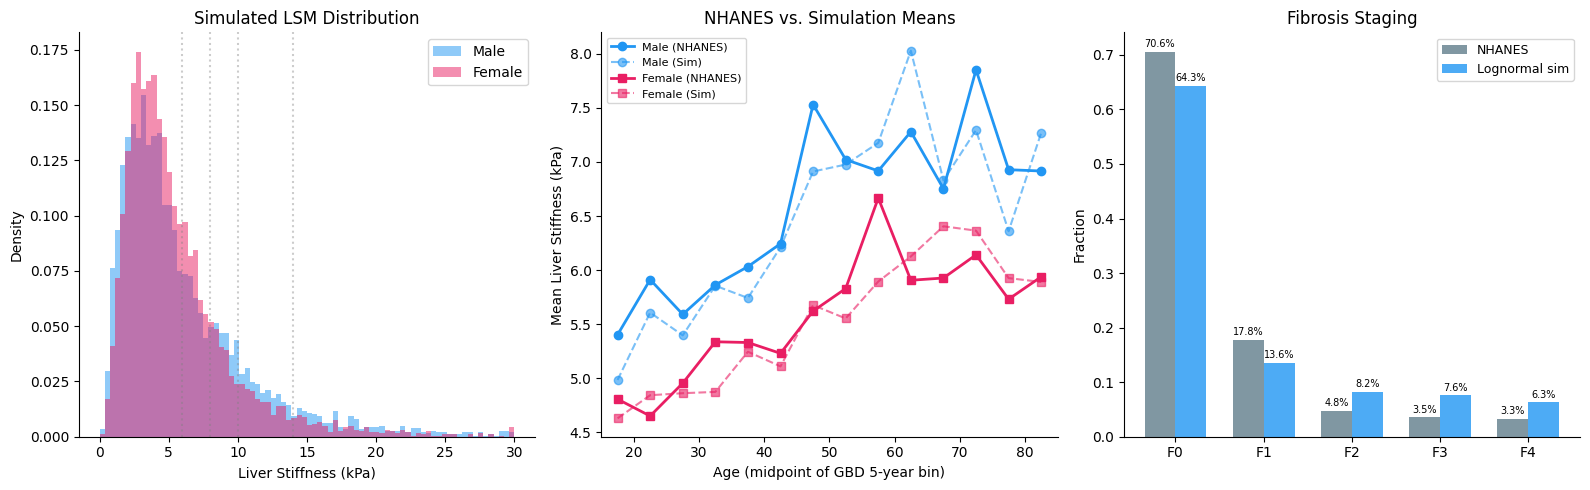

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: distribution of simulated exposures
ax = axes[0]
for sex, color in [('Male', '#2196F3'), ('Female', '#E91E63')]:
    sub = pop[pop['sex'] == sex]
    ax.hist(sub['liver_stiffness_kpa'], bins=80, alpha=0.5, color=color,
            label=sex, density=True, range=(0, 30))
ax.set_xlabel('Liver Stiffness (kPa)')
ax.set_ylabel('Density')
ax.set_title('Simulated LSM Distribution')
ax.legend()
for thr in FIBROSIS_BINS[1:-1]:
    ax.axvline(x=thr, color='gray', linestyle=':', alpha=0.4)
sns.despine(ax=ax)

# Middle: NHANES vs simulation means by age
ax = axes[1]
for sex, color, marker in [('Male', '#2196F3', 'o'), ('Female', '#E91E63', 's')]:
    sub_nhanes = comparison[comparison['sex'] == sex]
    age_mid = (sub_nhanes['age_start'] + sub_nhanes['age_end']) / 2
    ax.plot(age_mid, sub_nhanes['mean_lsm'],
            marker=marker, color=color, label=f'{sex} (NHANES)', linewidth=2)
    ax.plot(age_mid, sub_nhanes['sim_mean'],
            marker=marker, color=color, linestyle='--', alpha=0.6,
            label=f'{sex} (Sim)')
ax.set_xlabel('Age (midpoint of GBD 5-year bin)')
ax.set_ylabel('Mean Liver Stiffness (kPa)')
ax.set_title('NHANES vs. Simulation Means')
ax.legend(fontsize=8)
ax.set_xlim(15, 85)
sns.despine(ax=ax)

# Right: fibrosis fractions comparison
ax = axes[2]
x = np.arange(len(FIBROSIS_LABELS))
w = 0.35
ax.bar(x - w/2, nhanes_fibrosis.values, w,
       label='NHANES', color='#607D8B', alpha=0.8)
ax.bar(x + w/2, sim_fibrosis.values, w,
       label='Lognormal sim', color='#2196F3', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(FIBROSIS_LABELS)
ax.set_ylabel('Fraction')
ax.set_title('Fibrosis Staging')
ax.legend(fontsize=9)
for i, (nf, sf) in enumerate(zip(nhanes_fibrosis.values, sim_fibrosis.values)):
    ax.text(i - w/2, nf + 0.005, f'{nf:.1%}', ha='center', va='bottom', fontsize=7)
    ax.text(i + w/2, sf + 0.005, f'{sf:.1%}', ha='center', va='bottom', fontsize=7)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### Q-Q Plots: Simulation vs. NHANES by Age and Sex

To assess how well the lognormal model captures the empirical distribution,
we compare quantiles from the simulation against NHANES data for
representative age/sex strata.

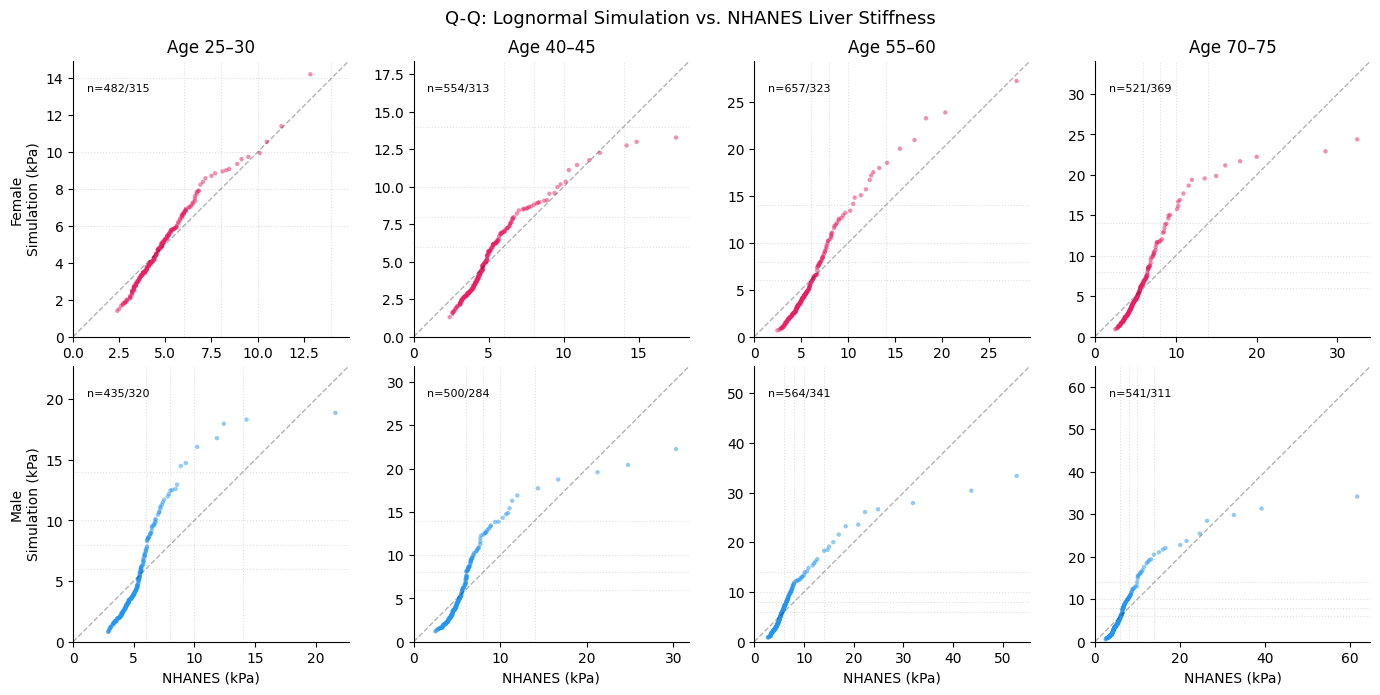

In [19]:
qq_ages = [(25, 30), (40, 45), (55, 60), (70, 75)]

fig, axes = plt.subplots(2, len(qq_ages), figsize=(14, 7))

for col, (a0, a1) in enumerate(qq_ages):
    for row, sex in enumerate(['Female', 'Male']):
        ax = axes[row, col]
        color = '#2196F3' if sex == 'Male' else '#E91E63'

        mask_e = ((nhanes_lsm['AGE'] >= a0) & (nhanes_lsm['AGE'] < a1)
                  & (nhanes_lsm['SEX'] == sex))
        emp = np.sort(nhanes_lsm.loc[mask_e, 'LSM_KPA'].values)

        mask_s = (pop['age'] >= a0) & (pop['age'] < a1) & (pop['sex'] == sex)
        sim_vals = np.sort(pop.loc[mask_s, 'liver_stiffness_kpa'].values)

        n_pts = min(len(emp), len(sim_vals), 200)
        if n_pts < 10:
            ax.text(0.5, 0.5, 'n < 10', transform=ax.transAxes, ha='center')
            continue

        probs = np.linspace(0.01, 0.99, n_pts)
        eq = np.quantile(emp, probs)
        sq = np.quantile(sim_vals, probs)

        ax.scatter(eq, sq, s=10, alpha=0.5, edgecolors='none', color=color)
        lim = max(eq.max(), sq.max()) * 1.05
        ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, linewidth=1)

        for thr in FIBROSIS_BINS[1:-1]:
            if thr < lim:
                ax.axhline(thr, color='gray', linestyle=':', alpha=0.25, linewidth=0.8)
                ax.axvline(thr, color='gray', linestyle=':', alpha=0.25, linewidth=0.8)

        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_aspect('equal')

        if row == 1:
            ax.set_xlabel('NHANES (kPa)')
        if col == 0:
            ax.set_ylabel(f'{sex}\nSimulation (kPa)')
        ax.set_title(f'Age {a0}\u2013{a1}' if row == 0 else '')
        ax.text(0.05, 0.92, f'n={len(emp)}/{len(sim_vals)}',
                transform=ax.transAxes, fontsize=8, va='top')

plt.suptitle('Q-Q: Lognormal Simulation vs. NHANES Liver Stiffness', fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

## 5. Simulant Trajectories Over Time

Each simulant has a fixed propensity (quantile in [0, 1]) and their liver
stiffness is the PPF of the lognormal distribution at that quantile, using
age/sex-specific mean and SD. As simulants age across 5-year bin boundaries,
their exposure updates. We track a handful of simulants over ~5 years.

In [20]:
from loguru import logger
from scipy.stats import norm as scipy_norm

logger.disable('vivarium')


def lognormal_params(mean, sd):
    """Convert (mean, sd) of X to (mu, sigma) of ln(X)."""
    sigma_sq = np.log(1 + (sd / mean) ** 2)
    return np.log(mean) - sigma_sq / 2, np.sqrt(sigma_sq)


def lognormal_cdf(x, mean, sd):
    mu, sigma = lognormal_params(mean, sd)
    return scipy_norm.cdf((np.log(x) - mu) / sigma)


def lognormal_ppf(p, mean, sd):
    mu, sigma = lognormal_params(mean, sd)
    return np.exp(mu + sigma * scipy_norm.ppf(p))


def lookup_params(age, sex, summary):
    """Look up (mean, sd) for an age/sex stratum from a summary table."""
    row = summary[(summary['sex'] == sex)
                  & (summary['age_start'] <= age)
                  & (summary['age_end'] > age)]
    if len(row) == 0:
        row = summary[summary['sex'] == sex].iloc[[-1]]
    return row['mean_lsm'].values[0], row['sd_lsm'].values[0]


# Get initial population
pop_init = sim.get_population(['age', 'sex', 'liver_stiffness.exposure'])
pop_init = pop_init.rename(columns={'liver_stiffness.exposure': 'lsm'})

# Select simulants near age-bin boundaries so transitions are visible
target_profiles = [
    ('Female', 29), ('Female', 44), ('Female', 64),
    ('Male', 34), ('Male', 54), ('Male', 69),
]

tracked = []
for sex, target_age in target_profiles:
    candidates = pop_init[pop_init['sex'] == sex]
    idx = (candidates['age'] - target_age).abs().idxmin()
    tracked.append(idx)

# Recover propensities from initial exposures
propensities = {}
for i in tracked:
    age, sex, lsm = pop_init.loc[i, ['age', 'sex', 'lsm']]
    mean, sd = lookup_params(age, sex, exposure_summary)
    propensities[i] = np.clip(lognormal_cdf(lsm, mean, sd), 0.001, 0.999)

print('Tracked simulants:')
for i in tracked:
    r = pop_init.loc[i]
    print(f'  #{i}: {r["sex"]}, age {r["age"]:.1f}, '
          f'p={propensities[i]:.3f}, LSM {r["lsm"]:.2f} kPa')

# Step simulation ~5 years (65 steps x 28 days)
N_STEPS = 65
records = []
for i in tracked:
    records.append({
        'simulant': i, 'time': sim.current_time,
        'age': pop_init.loc[i, 'age'], 'sex': pop_init.loc[i, 'sex'],
        'lsm': pop_init.loc[i, 'lsm'],
    })

for step in range(N_STEPS):
    sim.step()
    snap = sim.get_population(['age', 'liver_stiffness.exposure'])
    for i in tracked:
        records.append({
            'simulant': i, 'time': sim.current_time,
            'age': snap.loc[i, 'age'], 'sex': pop_init.loc[i, 'sex'],
            'lsm': snap.loc[i, 'liver_stiffness.exposure'],
        })

traj = pd.DataFrame(records)
print(f'\nCollected {len(traj)} points over {N_STEPS * 28 / 365.25:.1f} years')
print(f'Simulation time: {sim.current_time}')

Tracked simulants:
  #4083: Female, age 29.0, p=0.720, LSM 5.82 kPa
  #5331: Female, age 44.0, p=0.902, LSM 8.94 kPa
  #3820: Female, age 64.0, p=0.393, LSM 3.60 kPa
  #3681: Male, age 34.0, p=0.952, LSM 13.83 kPa
  #7148: Male, age 54.0, p=0.747, LSM 8.70 kPa
  #2693: Male, age 69.0, p=0.534, LSM 5.50 kPa



Collected 396 points over 5.0 years
Simulation time: 2028-12-25 00:00:00


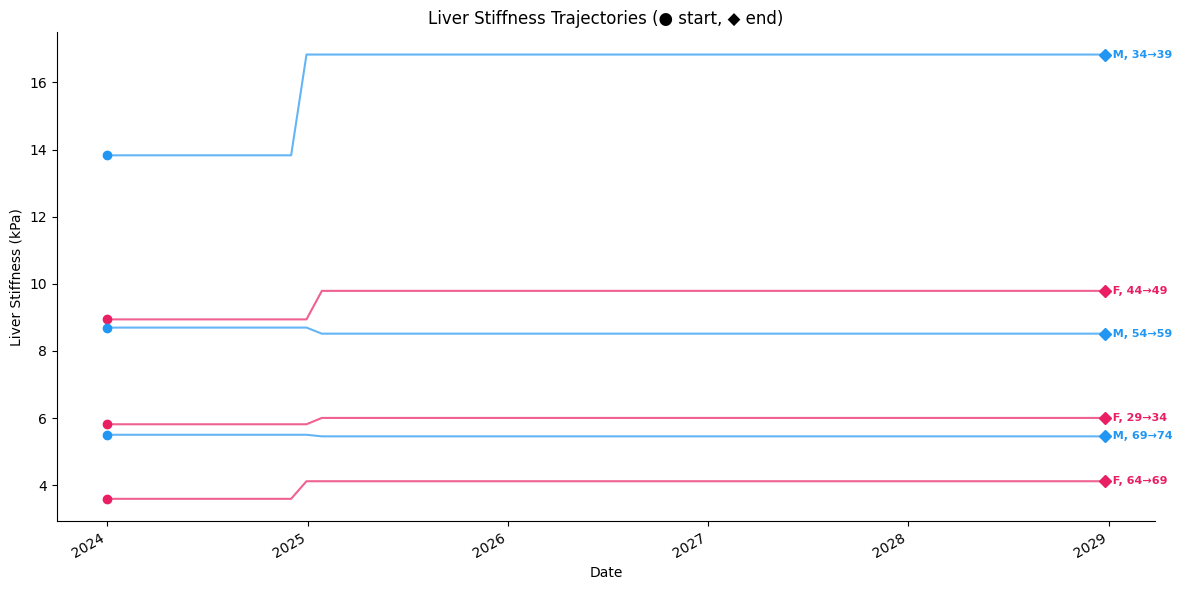

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

colors_sex = {'Female': '#E91E63', 'Male': '#2196F3'}

for sim_id in tracked:
    sub = traj[traj['simulant'] == sim_id]
    sex = sub['sex'].iloc[0]
    age0 = sub['age'].iloc[0]
    age1 = sub['age'].iloc[-1]
    color = colors_sex[sex]

    ax.plot(sub['time'], sub['lsm'], color=color, alpha=0.7, linewidth=1.5)
    ax.plot(sub['time'].iloc[0], sub['lsm'].iloc[0], 'o',
            color=color, markersize=6, zorder=5)
    ax.plot(sub['time'].iloc[-1], sub['lsm'].iloc[-1], 'D',
            color=color, markersize=6, zorder=5)

    # Direct text label at the end of each line
    ax.text(sub['time'].iloc[-1], sub['lsm'].iloc[-1],
            f'  {sex[0]}, {age0:.0f}\u2192{age1:.0f}',
            color=color, fontsize=8, va='center', fontweight='bold')

ax.set_xlabel('Date')
ax.set_ylabel('Liver Stiffness (kPa)')
ax.set_title('Liver Stiffness Trajectories (\u25cf start, \u25c6 end)')
fig.autofmt_xdate()
sns.despine()
plt.tight_layout()
plt.show()

## 6. Bootstrap Draws in a Single Artifact

In a real project with disease models and risk effects, parameter
uncertainty propagates through the entire simulation — incidence rates,
YLDs, DALYs, and other outcomes all depend on the input exposure
parameters. You can't derive analytical formulas for that propagation,
but you don't need to: store multiple parameter draws in the artifact,
run one simulation per draw, and the spread of results captures the
parameter uncertainty automatically.

This is the standard GBD/IHME "draws" pattern:

1. Bootstrap resample the source data to get N sets of (mean, SD)
2. Store all N draws as columns (`draw_0`, `draw_1`, ...) in one artifact
3. Run N simulations — each selects its draw via `input_draw_number`
4. Collect outputs — the distribution across draws = parameter uncertainty

We fix `additional_seed` to hold randomness constant across draws,
so the variation in outputs reflects parameter uncertainty alone.

In [22]:
import copy

np.random.seed(12345)
N_DRAWS = 10
DRAW_POP_SIZE = 2_000
DRAW_STEPS = 13  # ~1 year of 28-day steps

# --- Step 1: Bootstrap resample NHANES -> N sets of (mean, SD) per bin ---
bootstrap_summaries = []
for draw in range(N_DRAWS):
    boot_rows = []
    for (age_grp, sex), g in nhanes_lsm.groupby(['age_group', 'SEX'], observed=True):
        boot = g.sample(n=len(g), replace=True)
        age_start = int(age_grp.split('-')[0])
        age_end = int(age_grp.split('-')[1])
        boot_rows.append({
            'age_start': float(age_start), 'age_end': float(age_end),
            'sex': sex,
            'mean_lsm': weighted_mean(boot['LSM_KPA'].values, boot['WEIGHT'].values),
            'sd_lsm': weighted_std(boot['LSM_KPA'].values, boot['WEIGHT'].values),
        })
    bootstrap_summaries.append(pd.DataFrame(boot_rows))

print('Bootstrap variability in mean LSM (kPa):')
for sex in ['Female', 'Male']:
    for a_s in [25, 45, 65]:
        vals = [bs.loc[(bs['sex'] == sex) & (bs['age_start'] == a_s),
                       'mean_lsm'].values[0]
                for bs in bootstrap_summaries]
        print(f'  {sex} {a_s}-{a_s+5}: '
              f'{np.mean(vals):.2f} ({np.min(vals):.2f}\u2013{np.max(vals):.2f})')

# --- Step 2: Build multi-draw DataFrames for a single artifact ---
exp_base = build_artifact_table(bootstrap_summaries[0], 'mean_lsm',
                                YEAR_START, YEAR_END).drop(columns='value')
sd_base = build_artifact_table(bootstrap_summaries[0], 'sd_lsm',
                               YEAR_START, YEAR_END).drop(columns='value')

for draw, bs in enumerate(bootstrap_summaries):
    exp_single = build_artifact_table(bs, 'mean_lsm', YEAR_START, YEAR_END)
    sd_single = build_artifact_table(bs, 'sd_lsm', YEAR_START, YEAR_END)
    exp_base[f'draw_{draw}'] = exp_single['value'].values
    sd_base[f'draw_{draw}'] = sd_single['value'].values

# --- Step 3: Write single artifact with all draws ---
DRAW_ARTIFACT_PATH = os.path.join(OUTPUT_DIR, 'nhanes_lsm_draws.hdf')
if os.path.exists(DRAW_ARTIFACT_PATH):
    os.remove(DRAW_ARTIFACT_PATH)

draw_art = Artifact(DRAW_ARTIFACT_PATH)
draw_art.write('population.location', 'United States')
draw_art.write('population.structure', expand_years(pop_structure, YEAR_BINS))
draw_art.write('population.theoretical_minimum_risk_life_expectancy',
               expand_years(tmrle_table, YEAR_BINS))
draw_art.write('cause.all_causes.cause_specific_mortality_rate',
               expand_years(acmr_table, YEAR_BINS))
draw_art.write('risk_factor.liver_stiffness.distribution', 'lognormal')
draw_art.write('risk_factor.liver_stiffness.exposure',
               expand_years(exp_base, YEAR_BINS))
draw_art.write('risk_factor.liver_stiffness.exposure_standard_deviation',
               expand_years(sd_base, YEAR_BINS))

print(f'\nSingle artifact with {N_DRAWS} draws: {DRAW_ARTIFACT_PATH}')
print(f'Draw columns: {[c for c in exp_base.columns if "draw" in c]}')

# --- Step 4: Run N simulations, each selecting a different draw ---
TRACK_IDS = [100, 500, 1000, 1500]

draw_results = []
draw_trajectories = []

for draw in range(N_DRAWS):
    config = {
        'input_data': {
            'artifact_path': os.path.abspath(DRAW_ARTIFACT_PATH),
            'input_draw_number': draw,
        },
        'interpolation': {'order': 0, 'extrapolate': True},
        'randomness': {
            'map_size': 1_000_000,
            'key_columns': ['entrance_time', 'age'],
            'random_seed': 42,
            'additional_seed': 0,
        },
        'time': {
            'start': {'year': YEAR_START, 'month': 1, 'day': 1},
            'end': {'year': YEAR_START, 'month': 7, 'day': 1},
            'step_size': 28,
        },
        'population': {
            'population_size': DRAW_POP_SIZE,
            'initialization_age_min': 18,
            'initialization_age_max': 95,
        },
    }

    draw_sim = InteractiveContext(
        components=[BasePopulation(), Risk('risk_factor.liver_stiffness')],
        configuration=config,
    )

    dp = draw_sim.get_population(['age', 'sex', 'liver_stiffness.exposure'])
    dp = dp.rename(columns={'liver_stiffness.exposure': 'lsm'})

    draw_fib = fibrosis_fractions(dp['lsm'].values)
    draw_results.append({
        'draw': draw,
        'mean_lsm': dp['lsm'].mean(),
        'pct_above_8': (dp['lsm'] > 8).mean() * 100,
        **{lab: draw_fib[lab] for lab in FIBROSIS_LABELS},
    })

    for sid in TRACK_IDS:
        draw_trajectories.append({
            'draw': draw, 'simulant': sid,
            'time': draw_sim.current_time,
            'age': dp.loc[sid, 'age'],
            'sex': dp.loc[sid, 'sex'],
            'lsm': dp.loc[sid, 'lsm'],
        })

    for step in range(DRAW_STEPS):
        draw_sim.step()
        snap = draw_sim.get_population(['age', 'liver_stiffness.exposure'])
        for sid in TRACK_IDS:
            draw_trajectories.append({
                'draw': draw, 'simulant': sid,
                'time': draw_sim.current_time,
                'age': snap.loc[sid, 'age'],
                'sex': dp.loc[sid, 'sex'],
                'lsm': snap.loc[sid, 'liver_stiffness.exposure'],
            })

    print(f'  Draw {draw}: mean={dp["lsm"].mean():.2f}, '
          f'F4={draw_fib["F4"]:.1%}')

results_df = pd.DataFrame(draw_results)
traj_draws = pd.DataFrame(draw_trajectories)

print(f'\nAcross {N_DRAWS} draws:')
print(f'  Mean LSM: {results_df["mean_lsm"].mean():.2f} '
      f'({results_df["mean_lsm"].min():.2f}\u2013{results_df["mean_lsm"].max():.2f})')
for lab in FIBROSIS_LABELS:
    vals = results_df[lab]
    print(f'  {lab}: {vals.mean():.1%} ({vals.min():.1%}\u2013{vals.max():.1%})')

Bootstrap variability in mean LSM (kPa):
  Female 25-30: 4.97 (4.83–5.20)
  Female 45-50: 5.63 (5.27–5.99)
  Female 65-70: 5.89 (5.59–6.19)
  Male 25-30: 5.50 (5.20–5.84)
  Male 45-50: 7.70 (6.53–9.39)
  Male 65-70: 6.87 (6.59–7.42)



Single artifact with 10 draws: ./outputs/nhanes_lsm_draws.hdf
Draw columns: ['draw_0', 'draw_1', 'draw_2', 'draw_3', 'draw_4', 'draw_5', 'draw_6', 'draw_7', 'draw_8', 'draw_9']


  Draw 0: mean=6.39, F4=8.2%


  Draw 1: mean=6.30, F4=7.1%


  Draw 2: mean=6.23, F4=7.5%


...

  Draw 5: mean=6.32, F4=7.8%


  Draw 6: mean=6.16, F4=7.0%


  Draw 7: mean=6.19, F4=7.0%


  Draw 8: mean=6.34, F4=8.0%


  Draw 9: mean=6.33, F4=7.7%

Across 10 draws:
  Mean LSM: 6.31 (6.16–6.45)
  F0: 64.4% (63.7%–65.1%)
  F1: 12.3% (11.8%–12.8%)
  F2: 8.4% (7.8%–8.8%)
  F3: 7.2% (6.7%–7.8%)
  F4: 7.7% (7.0%–8.5%)


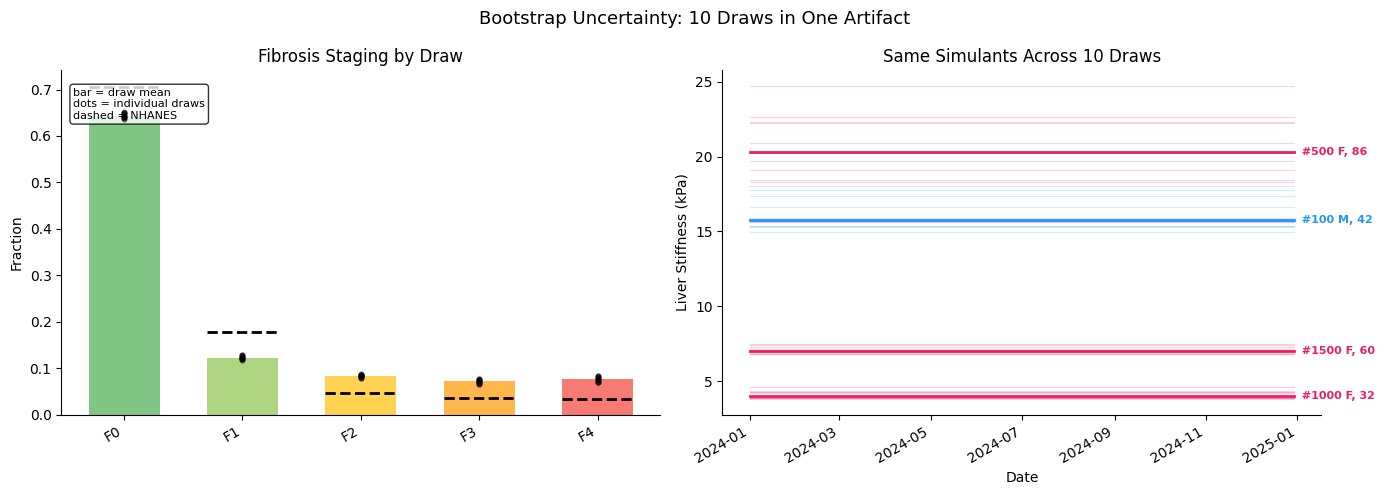

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: fibrosis fractions across draws vs. NHANES
ax = axes[0]
x = np.arange(len(FIBROSIS_LABELS))
for i, lab in enumerate(FIBROSIS_LABELS):
    vals = results_df[lab].values
    ax.bar(i, vals.mean(), color=FIBROSIS_COLORS[i], alpha=0.7, width=0.6)
    ax.scatter([i] * N_DRAWS, vals, color='black', s=12, alpha=0.4, zorder=5)
    ax.plot([i - 0.3, i + 0.3], [nhanes_fibrosis[lab]] * 2,
            color='black', linewidth=2, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(FIBROSIS_LABELS)
ax.set_ylabel('Fraction')
ax.set_title('Fibrosis Staging by Draw')
ax.text(0.02, 0.95, 'bar = draw mean\ndots = individual draws\ndashed = NHANES',
        transform=ax.transAxes, fontsize=8, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
sns.despine(ax=ax)

# Right: trajectory spaghetti with direct labels
ax = axes[1]
colors_sex = {'Female': '#E91E63', 'Male': '#2196F3'}

for sid in TRACK_IDS:
    sub_all = traj_draws[traj_draws['simulant'] == sid]
    sex = sub_all['sex'].iloc[0]
    age0 = sub_all['age'].iloc[0]
    color = colors_sex[sex]

    for draw in range(N_DRAWS):
        sub = sub_all[sub_all['draw'] == draw]
        ax.plot(sub['time'], sub['lsm'], color=color, alpha=0.2, linewidth=0.8)

    med = sub_all.groupby('time')['lsm'].median()
    ax.plot(med.index, med.values, color=color, linewidth=2)
    ax.text(med.index[-1], med.values[-1],
            f'  #{sid} {sex[0]}, {age0:.0f}',
            color=color, fontsize=8, va='center', fontweight='bold')

ax.set_xlabel('Date')
ax.set_ylabel('Liver Stiffness (kPa)')
ax.set_title('Same Simulants Across 10 Draws')
sns.despine(ax=ax)

fig.autofmt_xdate()
plt.suptitle('Bootstrap Uncertainty: 10 Draws in One Artifact', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Ensemble (Mixture) Distribution

A single lognormal may not capture the full shape of the LSM distribution,
especially the heavy right tail from individuals with fibrosis. Vivarium
supports ensemble distributions that mix multiple parametric forms. Here
we fit several distributions to the NHANES data, compute AIC-based
weights, and rebuild the simulation with the resulting mixture.

In [24]:
from scipy import stats as sp_stats

DIST_SCIPY = {
    'lnorm':   (sp_stats.lognorm,      {'floc': 0}),
    'gamma':   (sp_stats.gamma,         {'floc': 0}),
    'weibull': (sp_stats.weibull_min,   {'floc': 0}),
    'norm':    (sp_stats.norm,          {}),
    'llogis':  (sp_stats.fisk,          {'floc': 0}),
}

ALL_ENSEMBLE_DISTS = ['betasr', 'exp', 'gamma', 'gumbel', 'invgamma',
                      'invweibull', 'llogis', 'lnorm', 'mgamma',
                      'mgumbel', 'norm', 'weibull']

weight_rows = []
for (age_grp, sex), g in nhanes_lsm.groupby(['age_group', 'SEX'], observed=True):
    data = g['LSM_KPA'].values
    age_start = int(age_grp.split('-')[0])
    age_end = int(age_grp.split('-')[1])

    aic_dict = {}
    for dname, (dist, kwargs) in DIST_SCIPY.items():
        try:
            params = dist.fit(data, **kwargs)
            ll = np.sum(dist.logpdf(data, *params))
            if np.isfinite(ll):
                aic_dict[dname] = 2 * len(params) - 2 * ll
        except Exception:
            pass

    if aic_dict:
        aic_min = min(aic_dict.values())
        # Clip large AIC differences to avoid underflow in exp()
        raw_w = {}
        for d, a in aic_dict.items():
            delta = a - aic_min
            raw_w[d] = float(np.exp(-0.5 * delta)) if delta < 700 else 0.0
        total_w = sum(raw_w.values())
        bin_weights = {d: w / total_w for d, w in raw_w.items()}
    else:
        bin_weights = {'lnorm': 1.0}

    for dname in ALL_ENSEMBLE_DISTS:
        weight_rows.append({
            'sex': sex, 'age_start': float(age_start),
            'age_end': float(age_end),
            'year_start': YEAR_START, 'year_end': YEAR_END,
            'parameter': dname, 'value': bin_weights.get(dname, 0.0),
        })

ensemble_weights = pd.DataFrame(weight_rows)

# Show dominant distributions
print('Average AIC weights across all age/sex bins:')
for dname in ALL_ENSEMBLE_DISTS:
    mean_w = ensemble_weights[ensemble_weights['parameter'] == dname]['value'].mean()
    if mean_w > 0.001:
        print(f'  {dname:12s}: {mean_w:.4f}')

print('\nWeights for Female 45\u201350:')
sub = ensemble_weights[(ensemble_weights['sex'] == 'Female')
                       & (ensemble_weights['age_start'] == 45)]
for _, r in sub[sub['value'] > 0.001].iterrows():
    print(f'  {r["parameter"]:12s}: {r["value"]:.4f}')

Average AIC weights across all age/sex bins:
  llogis      : 1.0000

Weights for Female 45–50:
  llogis      : 1.0000


Ensemble artifact written



Ensemble sim: 10000 simulants
  Mean LSM: 6.06 kPa
  Median:   4.96 kPa


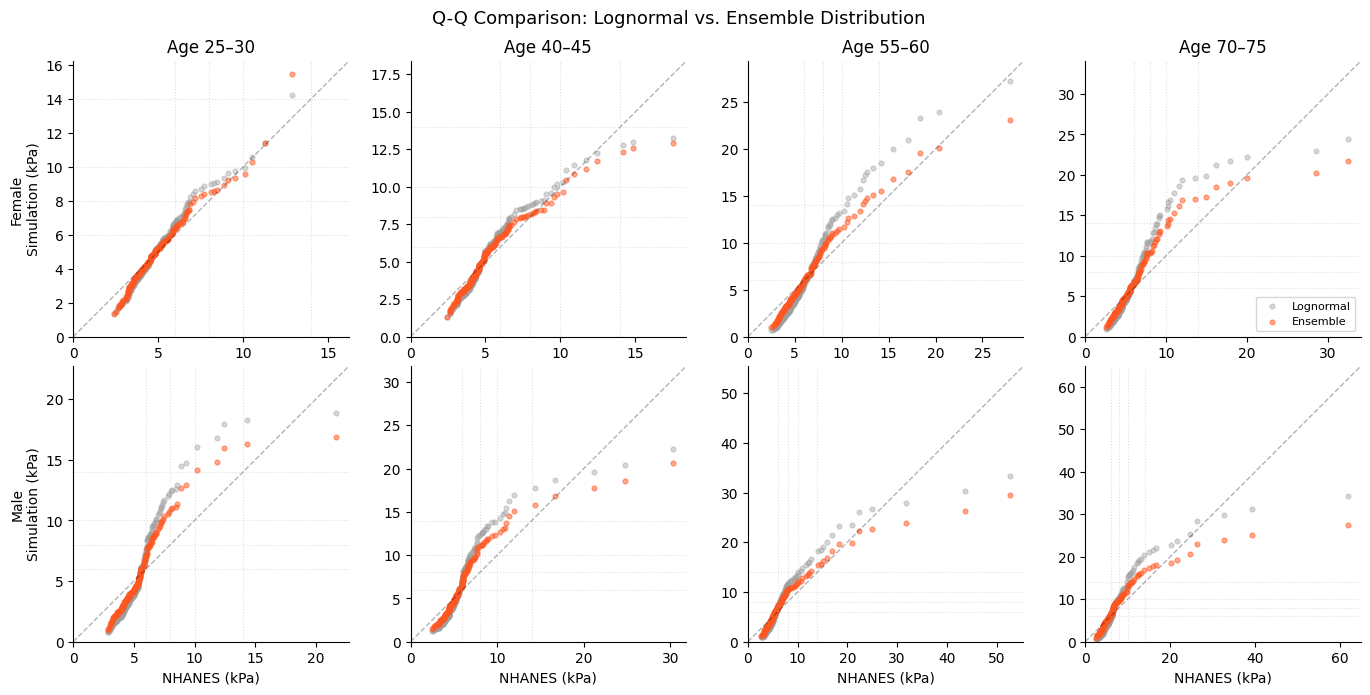

In [25]:
# Build ensemble artifact
ENSEMBLE_PATH = os.path.join(OUTPUT_DIR, 'nhanes_liver_stiffness_ensemble.hdf')
if os.path.exists(ENSEMBLE_PATH):
    os.remove(ENSEMBLE_PATH)

ens_artifact = Artifact(ENSEMBLE_PATH)
ens_artifact.write('population.location', 'United States')
ens_artifact.write('population.structure', expand_years(pop_structure, YEAR_BINS))
ens_artifact.write('population.theoretical_minimum_risk_life_expectancy',
                   expand_years(tmrle_table, YEAR_BINS))
ens_artifact.write('cause.all_causes.cause_specific_mortality_rate',
                   expand_years(acmr_table, YEAR_BINS))

ens_artifact.write('risk_factor.liver_stiffness.distribution', 'ensemble')
ens_artifact.write('risk_factor.liver_stiffness.exposure',
                   expand_years(exposure_table, YEAR_BINS))
ens_artifact.write('risk_factor.liver_stiffness.exposure_standard_deviation',
                   expand_years(exposure_sd_table, YEAR_BINS))
ens_artifact.write('risk_factor.liver_stiffness.exposure_distribution_weights',
                   expand_years(ensemble_weights, YEAR_BINS))

print('Ensemble artifact written\n')

# Run ensemble simulation
ens_sim = InteractiveContext(
    components=[BasePopulation(), Risk('risk_factor.liver_stiffness')],
    configuration={
        'input_data': {'artifact_path': os.path.abspath(ENSEMBLE_PATH)},
        'interpolation': {'order': 0, 'extrapolate': True},
        'randomness': {
            'map_size': 1_000_000,
            'key_columns': ['entrance_time', 'age'],
            'random_seed': 42,
        },
        'time': {
            'start': {'year': YEAR_START, 'month': 1, 'day': 1},
            'end': {'year': YEAR_START, 'month': 7, 'day': 1},
            'step_size': 28,
        },
        'population': {
            'population_size': 10_000,
            'initialization_age_min': 18,
            'initialization_age_max': 95,
        },
    },
)

ens_pop = ens_sim.get_population(['age', 'sex', 'liver_stiffness.exposure'])
ens_pop = ens_pop.rename(columns={'liver_stiffness.exposure': 'liver_stiffness_kpa'})

print(f'Ensemble sim: {len(ens_pop)} simulants')
print(f'  Mean LSM: {ens_pop["liver_stiffness_kpa"].mean():.2f} kPa')
print(f'  Median:   {ens_pop["liver_stiffness_kpa"].median():.2f} kPa')

# Q-Q comparison: lognormal vs ensemble
qq_ages = [(25, 30), (40, 45), (55, 60), (70, 75)]

fig, axes = plt.subplots(2, len(qq_ages), figsize=(14, 7))

for col, (a0, a1) in enumerate(qq_ages):
    for row, sex in enumerate(['Female', 'Male']):
        ax = axes[row, col]
        mask_e = ((nhanes_lsm['AGE'] >= a0) & (nhanes_lsm['AGE'] < a1)
                  & (nhanes_lsm['SEX'] == sex))
        emp = np.sort(nhanes_lsm.loc[mask_e, 'LSM_KPA'].values)

        n_pts = min(len(emp), 200)
        probs = np.linspace(0.01, 0.99, n_pts)
        eq = np.quantile(emp, probs)

        mask_ln = (pop['age'] >= a0) & (pop['age'] < a1) & (pop['sex'] == sex)
        ln_vals = pop.loc[mask_ln, 'liver_stiffness_kpa'].values
        ln_q = np.quantile(ln_vals, probs) if len(ln_vals) >= 10 else eq * np.nan

        mask_en = (ens_pop['age'] >= a0) & (ens_pop['age'] < a1) & (ens_pop['sex'] == sex)
        en_vals = ens_pop.loc[mask_en, 'liver_stiffness_kpa'].values
        en_q = np.quantile(en_vals, probs) if len(en_vals) >= 10 else eq * np.nan

        ax.scatter(eq, ln_q, s=12, alpha=0.4, color='#9E9E9E', label='Lognormal')
        ax.scatter(eq, en_q, s=12, alpha=0.5, color='#FF5722', label='Ensemble')

        lim = np.nanmax([eq.max(), np.nanmax(ln_q), np.nanmax(en_q)]) * 1.05
        ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, linewidth=1)

        for thr in FIBROSIS_BINS[1:-1]:
            if thr < lim:
                ax.axhline(thr, color='gray', linestyle=':', alpha=0.25, linewidth=0.8)
                ax.axvline(thr, color='gray', linestyle=':', alpha=0.25, linewidth=0.8)

        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_aspect('equal')

        if row == 1:
            ax.set_xlabel('NHANES (kPa)')
        if col == 0:
            ax.set_ylabel(f'{sex}\nSimulation (kPa)')
        ax.set_title(f'Age {a0}\u2013{a1}' if row == 0 else '')
        if row == 0 and col == len(qq_ages) - 1:
            ax.legend(fontsize=8, loc='lower right')

plt.suptitle('Q-Q Comparison: Lognormal vs. Ensemble Distribution', fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

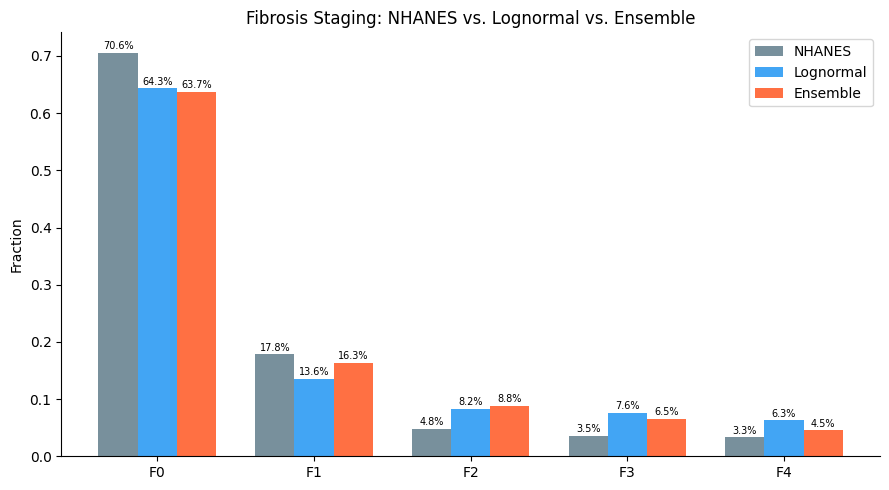

Fibrosis staging comparison:


,F0,F1,F2,F3,F4
NHANES (weighted),70.6%,17.8%,4.8%,3.5%,3.3%
Lognormal (10k sim),64.3%,13.6%,8.2%,7.6%,6.3%
Ensemble (10k sim),63.7%,16.3%,8.8%,6.5%,4.5%
Bootstrap lognormal (mean of 10 draws),64.4%,12.3%,8.4%,7.2%,7.7%



F3+F4 (advanced fibrosis + cirrhosis):
  NHANES (weighted): 6.8%
  Lognormal (10k sim): 13.9%
  Ensemble (10k sim): 11.1%
  Bootstrap lognormal (mean of 10 draws): 14.9%

F4 (cirrhosis) comparison:
  NHANES (weighted): 3.29%
  Lognormal (10k sim): 6.29%
  Ensemble (10k sim): 4.55%
  Bootstrap lognormal (mean of 10 draws): 7.71%


In [26]:
# --- Fibrosis staging comparison: NHANES vs. Lognormal vs. Ensemble ---
ens_fibrosis = fibrosis_fractions(ens_pop['liver_stiffness_kpa'].values)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(FIBROSIS_LABELS))
w = 0.25
ax.bar(x - w, nhanes_fibrosis.values, w, label='NHANES', color='#607D8B', alpha=0.85)
ax.bar(x,     sim_fibrosis.values, w, label='Lognormal', color='#2196F3', alpha=0.85)
ax.bar(x + w, ens_fibrosis.values, w, label='Ensemble', color='#FF5722', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(FIBROSIS_LABELS)
ax.set_ylabel('Fraction')
ax.set_title('Fibrosis Staging: NHANES vs. Lognormal vs. Ensemble')
ax.legend()
for i in range(len(FIBROSIS_LABELS)):
    for frac, dx in zip(
        [nhanes_fibrosis.values[i], sim_fibrosis.values[i], ens_fibrosis.values[i]],
        [-w, 0, w]):
        ax.text(i + dx, frac + 0.003, f'{frac:.1%}',
                ha='center', va='bottom', fontsize=7)
sns.despine()
plt.tight_layout()
plt.show()

# Comparison table
comp_df = pd.DataFrame({
    'NHANES (weighted)': nhanes_fibrosis,
    'Lognormal (10k sim)': sim_fibrosis,
    'Ensemble (10k sim)': ens_fibrosis,
    'Bootstrap lognormal (mean of 10 draws)': results_df[FIBROSIS_LABELS].mean(),
}).T
comp_df.columns = FIBROSIS_LABELS

print('Fibrosis staging comparison:')
display(comp_df.style.format('{:.1%}'))

print(f'\nF3+F4 (advanced fibrosis + cirrhosis):')
for name, row in comp_df.iterrows():
    print(f'  {name}: {row["F3"] + row["F4"]:.1%}')

print(f'\nF4 (cirrhosis) comparison:')
for name, row in comp_df.iterrows():
    print(f'  {name}: {row["F4"]:.2%}')

## Summary

This notebook demonstrated the full pipeline from NHANES survey data to
vivarium microsimulation, with extensions for validation and uncertainty:

1. **Data** -- downloaded NHANES liver stiffness from 2 cycles (14,192 adults)
2. **Analysis** -- weighted mean and SD by GBD 5-year age groups and sex
3. **Artifact** -- lognormal risk factor exposure for vivarium
4. **Simulation** -- 10,000 simulants with Q-Q validation against NHANES
5. **Trajectories** -- tracked individual exposure paths as simulants age
6. **Bootstrap draws** -- 10 artifacts with bootstrap parameters, showing how
   parameter uncertainty propagates through the simulation pipeline (GBD/IHME "draws" pattern)
7. **Ensemble** -- AIC-weighted mixture distribution from data

To extend for a real project, you would add actual population and mortality
data from GBD, disease models affected by liver stiffness (e.g., cirrhosis,
HCC), risk effects linking liver stiffness to disease transitions, and more
bootstrap draws for robust uncertainty quantification.